In [2]:
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import sys
from pathlib import Path
import re
import networkx as nx

In [3]:


def get_repo_root():
    # --- CASE 1: Running inside a notebook ---
    if 'ipykernel' in sys.modules:
        # notebook file is usually inside <root>/scripts/... or <root>/analysis/...
        # so take the notebook cwd and go UP until we find the repo
        cwd = Path().resolve()
        # We assume the notebook is in <root>/scripts or <root>/analysis>
        # → repo root = parent folder
        return cwd.parents[0]

    # --- CASE 2: Running as a .py file ---
    return Path(__file__).resolve().parents[1]

REPO_ROOT = get_repo_root()
print("Detected REPO_ROOT =", REPO_ROOT)


Detected REPO_ROOT = D:\repos\refactored_MDM


In [4]:
MOTION_DIR = REPO_ROOT / "GigaHands_Data" / "coverted_motions" / "hand_poses_xyz"
ANNOTATIONS = REPO_ROOT / "GigaHands_Data" / "annotations_v2.jsonl"
INFERENCE = REPO_ROOT / "save" / "test_custom500_concat_11_4" / "infer_trainset"   # Adjust as needed

print(MOTION_DIR)
print(INFERENCE)


D:\repos\refactored_MDM\GigaHands_Data\coverted_motions\hand_poses_xyz
D:\repos\refactored_MDM\save\test_custom500_concat_11_4\infer_trainset


## 1) Load FILE_LIST
This section reads the `file_list.js` file created during inference.  
It extracts the list of generated motion files (JSONL paths + scene/sequence/text metadata) and loads it into Python so we know which motion files exist and where they are located.

## 2) Load generated motions (.jsonl)
This section iterates over every filename from the FILE_LIST.  
For each motion:
- open the `.jsonl` file,
- read every frame,
- extract the XYZ values,
- flatten them into a numeric vector,
- and store the result in a NumPy array.

The result: a list of full motion sequences (`motions`) and their corresponding texts (`texts`).


In [11]:
# -------------------------------------------------------------
# ASSUME THESE ARE ALREADY DEFINED ABOVE:
# REPO_ROOT, MOTION_DIR, ANNOTATIONS, INFERENCE, INFER_DIR
# -------------------------------------------------------------

FILE_LIST_JS = INFERENCE / "file_list.js"

print("REPO_ROOT    :", REPO_ROOT)
print("MOTION_DIR   :", MOTION_DIR)
print("ANNOTATIONS  :", ANNOTATIONS)
print("INFER_DIR    :", INFERENCE)
print("FILE_LIST_JS :", FILE_LIST_JS)


# ================================
# 1) Load FILE_LIST
# ================================
def load_file_list(js_path: Path):
    """
    Robust parser for file_list.js:
      const FILE_LIST = [ {...}, {...} ];
      export default FILE_LIST;
    """
    content = js_path.read_text(encoding="utf-8")

    # Extract only the [...array...] block
    arr = re.search(r"\[(.*)\]", content, re.DOTALL)
    if not arr:
        raise ValueError(f"Cannot parse FILE_LIST array inside {js_path}")

    return json.loads("[" + arr.group(1) + "]")


file_list = load_file_list(FILE_LIST_JS)
N = len(file_list)
print(f"Loaded FILE_LIST with {N} entries")


# ================================
# 2) Load generated motions (.jsonl)
# ================================
def load_motion_jsonl(jsonl_path: Path) -> np.ndarray:
    """
    Return shape [T, 3J] where J = number of joints.
    """
    frames = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            pts = np.array(json.loads(line), dtype=np.float32)   # [J,4]
            xyz = pts[:, :3].reshape(-1)                        # flatten
            frames.append(xyz)

    return np.stack(frames, axis=0)


motions = []
texts = []

for i, entry in enumerate(file_list):
    fname = entry["filename"]
    path = INFERENCE / fname
    if not path.exists():
        raise FileNotFoundError(f"Missing motion file: {path}")

    motion = load_motion_jsonl(path)
    motions.append(motion)
    texts.append(entry.get("text", f"idx_{i}"))

    if i < 3:
        print(f"[{i}] {fname} → motion shape {motion.shape}")

print("Loaded all motions.")


REPO_ROOT    : D:\repos\refactored_MDM
MOTION_DIR   : D:\repos\refactored_MDM\GigaHands_Data\coverted_motions\hand_poses_xyz
ANNOTATIONS  : D:\repos\refactored_MDM\GigaHands_Data\annotations_v2.jsonl
INFER_DIR    : D:\repos\refactored_MDM\save\test_custom500_concat_11_4\infer_trainset
FILE_LIST_JS : D:\repos\refactored_MDM\save\test_custom500_concat_11_4\infer_trainset\file_list.js
Loaded FILE_LIST with 20 entries
[0] 00_p005-gopro_009_text_Capture_the_tree_marker_by_pressing_the_capture_button_on_the_GoPro.jsonl → motion shape (253, 126)
[1] 01_p013-fastfood-sandwich_080_text_Slice_the_spam_into_even_pieces_on_the_cutting_board.jsonl → motion shape (253, 126)
[2] 02_p025-firstaid_017_text_Wipe_the_wound_on_the_wrist_thoroughly_to_clean_it_using_the_wipe_pad_gripped_with_the_tweezer.jsonl → motion shape (253, 126)
Loaded all motions.


## 3) Compute DTW matrix
This section computes a full pairwise distance matrix between all generated motions.
For each pair of motions `(i, j)`, we use DTW (Dynamic Time Warping) with Euclidean distance
to measure how similar the two motion sequences are over time.
The result is an `N × N` matrix where `dtw_matrix[i,j]` is the motion distance.

## 4) Build motion-space kNN graph
Using the DTW matrix, we construct a directed k-nearest neighbors graph.
For each motion `i`, we:
- sort all other motions by DTW distance,
- select the top `k` closest motions,
- create edges `i → j` labeled with their DTW distance.

Each node corresponds to one generated motion, and carries its scene label.
This graph represents motion-space similarity between all generated samples.


## 🔹 What is DTW?
DTW (Dynamic Time Warping) is a method for measuring similarity between two motion sequences
even if they are not aligned in time.

It finds the best way to "warp" one sequence to match the other by:
- stretching or compressing time,
- matching frames that happen at slightly different speeds,
- comparing motions of different lengths or timing.

This makes DTW ideal for motion comparison, because two motions can be similar
even if one is performed faster or slower.


In [6]:
# ================================
# 3) Compute DTW matrix
# ================================
def dtw_distance(a, b):
    dist, _ = fastdtw(a, b, dist=euclidean)
    return dist


print("Computing DTW...\n")
dtw_matrix = np.zeros((N, N), dtype=np.float32)

for i in range(N):
    for j in range(i+1, N):
        d = dtw_distance(motions[i], motions[j])
        dtw_matrix[i,j] = dtw_matrix[j,i] = d
    print(f"Row {i+1}/{N} done")

print("\nDTW matrix shape:", dtw_matrix.shape)


# ================================
# 4) Build motion-space kNN graph
# ================================
k = 5
G = nx.DiGraph()

# 🔥 Node label = scene (e.g. "p013-fastfood-sandwich")
for i, entry in enumerate(file_list):
    scene = entry["scene"]
    G.add_node(i, label=scene)

for i in range(N):
    neighbors = [(j, dtw_matrix[i,j]) for j in range(N) if j != i]
    neighbors.sort(key=lambda x: x[1])

    for j, d in neighbors[:k]:
        G.add_edge(i, j, weight=d, distance=float(d))

Computing DTW...

Row 1/20 done
Row 2/20 done
Row 3/20 done
Row 4/20 done
Row 5/20 done
Row 6/20 done
Row 7/20 done
Row 8/20 done
Row 9/20 done
Row 10/20 done
Row 11/20 done
Row 12/20 done
Row 13/20 done
Row 14/20 done
Row 15/20 done
Row 16/20 done
Row 17/20 done
Row 18/20 done
Row 19/20 done
Row 20/20 done

DTW matrix shape: (20, 20)


## 5) Plot graph
This section visualizes the motion-space kNN graph created earlier.

A spring-layout (`nx.spring_layout`) places nodes so that:
- closer motions (low DTW distance) appear closer in the plot,
- edges represent nearest neighbors.

### What the plot shows:
- **Nodes**: each generated motion, labeled with its scene name.
- **Edges**: arrows from each motion to its k nearest neighbors.
- **Edge labels**: DTW distances, rounded for readability.

The final figure gives a visual map of how motions cluster in motion-space based on DTW similarity.


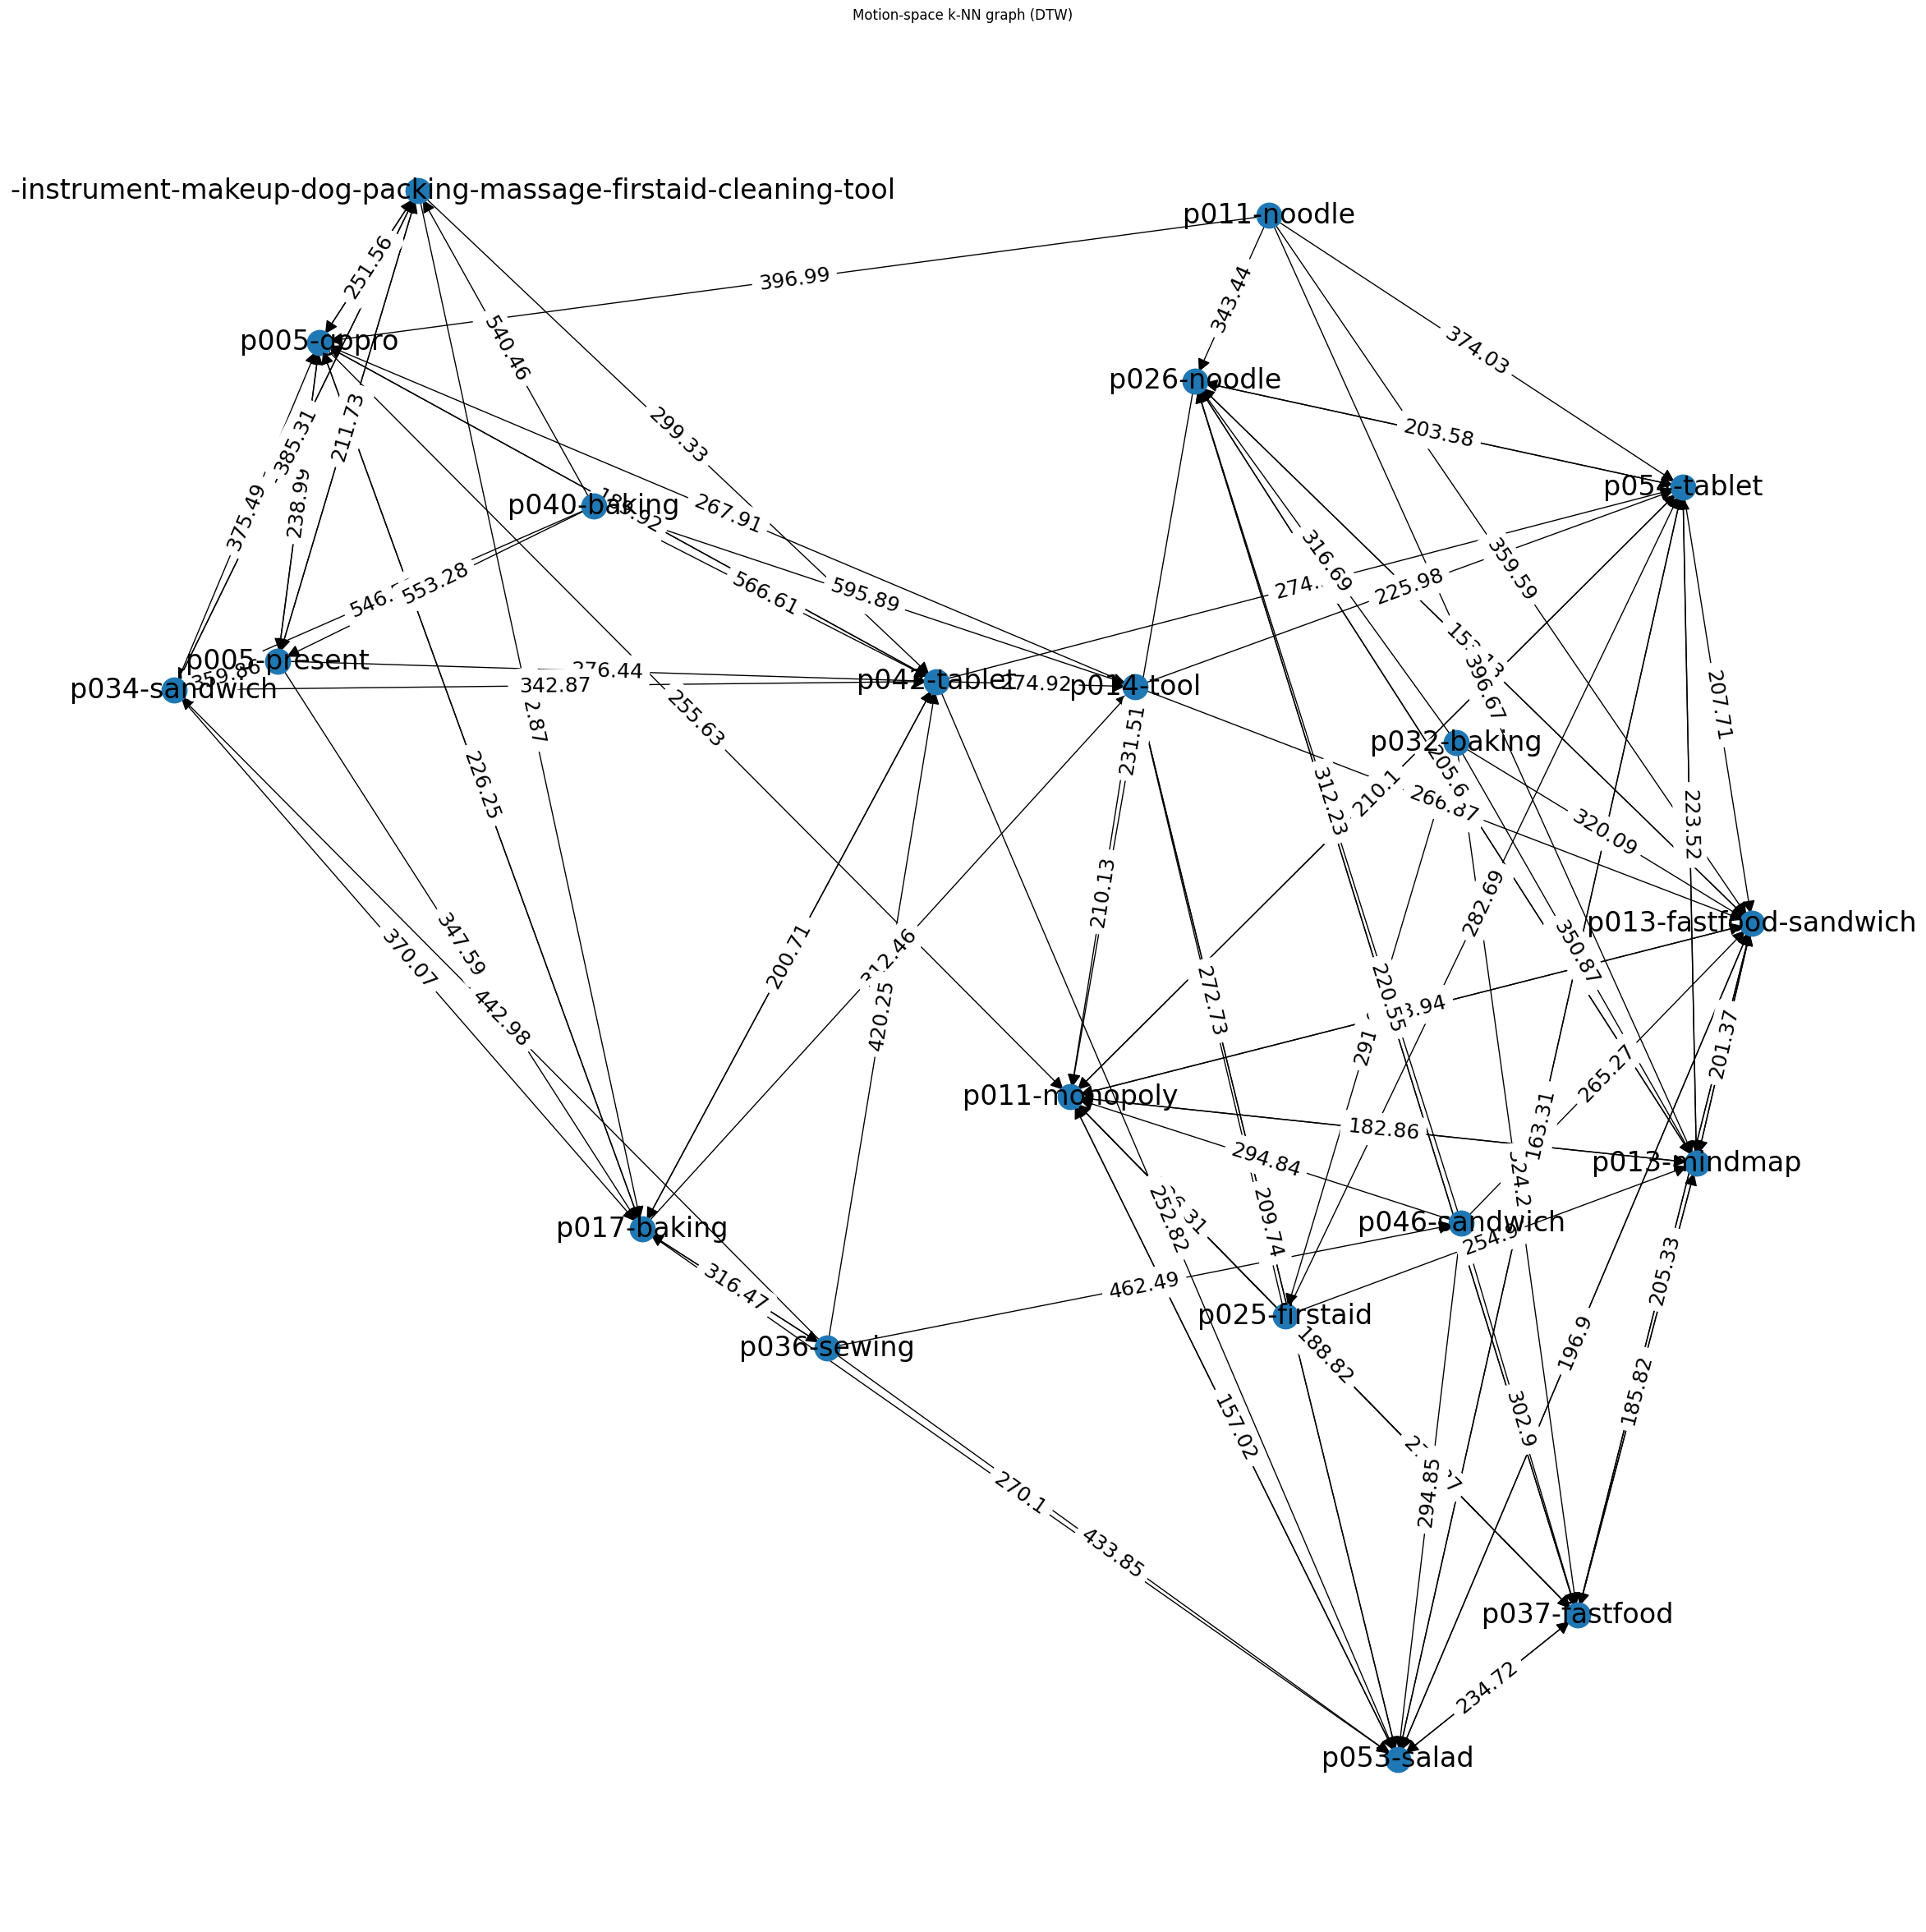

In [7]:
# ================================
# 5) Plot graph
# ================================
plt.figure(figsize=(30,30))
pos = nx.spring_layout(G, weight="weight", seed=42, k=4)
nx.draw_networkx_nodes(G, pos, node_size=480)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=24)
nx.draw_networkx_labels(
    G, pos,
    labels={i: G.nodes[i]["label"] for i in range(N)},
    font_size=24
)


# 🔥 draw distance values on edges
# 🔥 rounded distance labels
edge_labels = { (u, v): round(d, 2) for (u, v), d in nx.get_edge_attributes(G, 'distance').items() }
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=18)



plt.title("Motion-space k-NN graph (DTW)")
plt.axis("off")
plt.show()

## 6) Motion-space DTW heatmap
This section visualizes the full DTW distance matrix as a heatmap.

Each cell `(i, j)` shows the DTW distance between motion `i` and motion `j`:
- **Low distance (green)** → motions are very similar  
- **High distance (red)** → motions are very different

Scene labels are added to the x/y axes so you can see which scenes cluster together.
This helps identify natural motion groups, outliers, or redundant samples in the dataset.


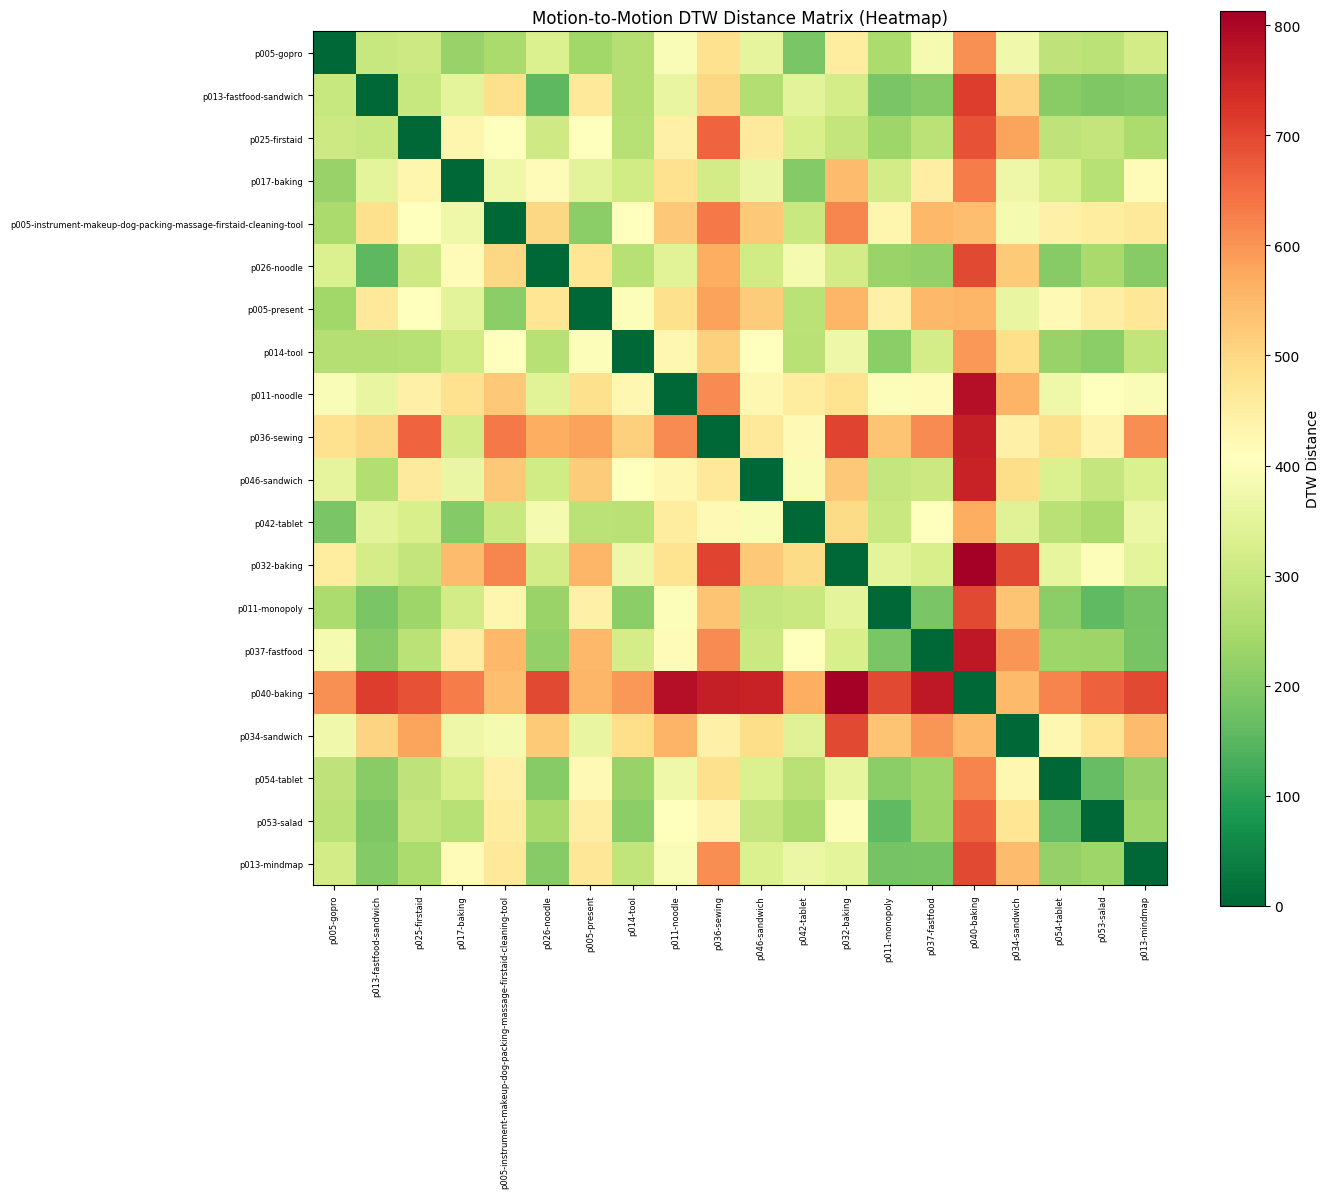

In [8]:
# ================================
# 6) Motion-space DTW heatmap
# ================================
plt.figure(figsize=(14, 12))

plt.imshow(dtw_matrix, cmap="RdYlGn_r")
plt.colorbar(label='DTW Distance')

# Optional: scene labels on axes
labels = [entry["scene"] for entry in file_list]
plt.xticks(range(N), labels, rotation=90, fontsize=6)
plt.yticks(range(N), labels, fontsize=6)

plt.title("Motion-to-Motion DTW Distance Matrix (Heatmap)")
plt.tight_layout()
plt.show()


In [9]:
labels = [entry["scene"] for entry in file_list]
sequences = [entry["sequence"] for entry in file_list]
combined_labels = [f"{scene}_{seq}" for scene, seq in zip(labels, sequences)]


In [10]:
import numpy as np
import json
from pathlib import Path

SAVE_DIR = Path(".")   # current folder

# Save matrix
np.save(SAVE_DIR / "motion_space_dtw_matrix.npy", dtw_matrix)

# Save labels
with open(SAVE_DIR / "motion_space_labels.json", "w") as f:
    json.dump(combined_labels, f, indent=4)

print("Saved:")
print(" - motion_space_dtw_matrix.npy")
print(" - motion_space_labels.json")


Saved:
 - motion_space_dtw_matrix.npy
 - motion_space_labels.json
